Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Create Folder Structure

In [2]:
import os
BASE = '/content/drive/MyDrive/SocBiz_Analytics_Project'

folders = [
    f'{BASE}/data/raw',
    f'{BASE}/data/processed',
    f'{BASE}/outputs/plots',
    f'{BASE}/outputs/csv'
]

for folder in folders:
    if not os.path.exists(folder):
        os.makedirs(folder)
        print(f"Created: {folder}")
    else:
        print(f"Already exists (no changes made): {folder}")

Created: /content/drive/MyDrive/SocBiz_Analytics_Project/data/raw
Created: /content/drive/MyDrive/SocBiz_Analytics_Project/data/processed
Created: /content/drive/MyDrive/SocBiz_Analytics_Project/outputs/plots
Created: /content/drive/MyDrive/SocBiz_Analytics_Project/outputs/csv


Install Libraries

In [3]:
!pip install lightgbm xgboost openpyxl -q
print("Libraries installed")

Libraries installed


Import Everything

In [4]:
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)

# Paths are defined
BASE        = '/content/drive/MyDrive/SocBiz_Analytics_Project'
RAW         = f'{BASE}/data/raw'
PROCESSED   = f'{BASE}/data/processed'
PLOTS       = f'{BASE}/outputs/plots'
CSV_OUT     = f'{BASE}/outputs/csv'

print("All imports done ")
print(f"Base path: {BASE}")

All imports done 
Base path: /content/drive/MyDrive/SocBiz_Analytics_Project


Upload Your Files

In [5]:
import shutil
from google.colab import files

print("Select ACN data and all Urban EV data together...")
uploaded = files.upload()

for filename in uploaded.keys():
    src = f'/content/{filename}'
    dst = f'{RAW}/{filename}'

    # If file already exists, delete it first
    if os.path.exists(dst):
        os.remove(dst)
        print(f"Overwriting existing file: {filename}")

    shutil.move(src, dst)
    print(f"Saved: {filename}")



Select ACN data and all Urban EV data together...


Saving stations.csv to stations.csv
Saving adj.csv to adj.csv
Saving duration.csv to duration.csv
Saving distance.csv to distance.csv
Saving information.csv to information.csv
Saving occupancy.csv to occupancy.csv
Saving price.csv to price.csv
Saving time.csv to time.csv
Saving volume.csv to volume.csv
Saving acndata_sessions.json.xlsx to acndata_sessions.json.xlsx
Saved: stations.csv
Saved: adj.csv
Saved: duration.csv
Saved: distance.csv
Saved: information.csv
Saved: occupancy.csv
Saved: price.csv
Saved: time.csv
Saved: volume.csv
Saved: acndata_sessions.json.xlsx


Verify All Files Are There

In [6]:
raw_files = os.listdir(RAW)
print(f"Total files in raw folder: {len(raw_files)}")
print()
for f in sorted(raw_files):
    size = os.path.getsize(f'{RAW}/{f}')
    print(f"{f} - {size/1024:.1f} KB")

Total files in raw folder: 10

acndata_sessions.json.xlsx - 1345.1 KB
adj.csv - 121.2 KB
distance.csv - 254.6 KB
duration.csv - 20298.8 KB
information.csv - 10.5 KB
occupancy.csv - 5443.6 KB
price.csv - 15527.5 KB
stations.csv - 55.2 KB
time.csv - 144.5 KB
volume.csv - 20289.7 KB


Looking at the urban EV data

In [7]:
csv_files = {
    'stations'    : 'stations.csv',
    'information' : 'information.csv',
    'occupancy'   : 'occupancy.csv',
    'volume'      : 'volume.csv',
    'duration'    : 'duration.csv',
    'price'       : 'price.csv',
    'time'        : 'time.csv',
    'adj'         : 'adj.csv',
    'distance'    : 'distance.csv'
}

for name, fname in csv_files.items():
    df = pd.read_csv(f'{RAW}/{fname}', nrows=2)
    print(f"FILE: {name.upper()}")
    print(f"Columns ({len(df.columns)}): {df.columns.tolist()[:6]}{'...' if len(df.columns)>6 else ''}")
    print(df.head(2))
    print()

FILE: STATIONS
Columns (6): ['station_id', 'latitude', 'longitude', 'fast', 'slow', 'count']
   station_id  latitude  longitude  fast  slow  count
0           1   22.7163   113.8263     5     5     10
1           2   22.6789   114.0497    20     0     20

FILE: INFORMATION
Columns (10): ['num', 'grid', 'count', 'fast_count', 'slow_count', 'area']...
   num  grid  count  fast_count  slow_count   area      lon      la  CBD  \
0    1   102     30           3          27 0.7100 114.1030 22.5404    0   
1    3   105     93           0          93 0.7700 114.1208 22.5513    0   

   dynamic_pricing  
0                0  
1                0  

FILE: OCCUPANCY
Columns (248): ['timestamp', '102', '105', '107', '108', '109']...
   timestamp  102  105  107  108  109  110  111  115  123  ...  1160  1162  \
0          1   12   16   24   15    6    8   24    1    2  ...     0    12   
1          2   12   16   24   15    6    8   24    1    2  ...     0    12   

   1163  1164  1166  1167  1168  1170

Looking at the ACN dataset

In [8]:
df_acn_peek = pd.read_excel(f'{RAW}/acndata_sessions.json.xlsx', nrows=3)
print("ACN FILE")
print(f"Columns: {df_acn_peek.columns.tolist()}")
print(df_acn_peek.head(3))

ACN FILE
Columns: ['_meta', 'end', 'min_kWh', 'site', 'start', '_items', '_id', 'clusterID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'userInputs', 'WhPerMile', 'kWhRequested', 'milesRequested', 'minutesAvailable', 'modifiedAt', 'paymentRequired', 'requestedDeparture', 'userID.1']
   _meta  end  min_kWh     site  start  _items                       _id  \
0    NaN  NaN      NaN  caltech    NaN     NaN  5bc90cb9f9af8b0d7fe77cd2   
1    NaN  NaN      NaN      NaN    NaN     NaN  5bc90cb9f9af8b0d7fe77cd3   
2    NaN  NaN      NaN      NaN    NaN     NaN  5bc90cb9f9af8b0d7fe77cd4   

   clusterID                 connectionTime                 disconnectTime  \
0         39  Wed, 25 Apr 2018 11:08:04 GMT  Wed, 25 Apr 2018 13:20:10 GMT   
1         39  Wed, 25 Apr 2018 13:45:10 GMT  Thu, 26 Apr 2018 00:56:16 GMT   
2         39  Wed, 25 Apr 2018 13:45:50 GMT  Wed, 25 Apr 2018 23:04:45 GMT   



Load Time File

In [9]:
# Load time file - this maps timestamp number to real datetime
df_time = pd.read_csv(f'{RAW}/time.csv')
print("TIME FILE:")
print(df_time.shape)
print(df_time.head(3))

TIME FILE:
(8640, 6)
   month  day  year  hour  minute  second
0      6   19  2022     0       0       0
1      6   19  2022     0       5       0
2      6   19  2022     0      10       0


Create Proper Datetime Column

In [10]:
# Combine all time columns into one datetime and only keep that
df_time['datetime'] = pd.to_datetime(df_time[['year','month','day','hour','minute','second']])
df_time['timestamp'] = df_time.index + 1
df_time = df_time[['timestamp', 'datetime']]

print(f"Total timestamps: {len(df_time)}")
print(f"Start: {df_time['datetime'].min()}")
print(f"End:   {df_time['datetime'].max()}")
print(df_time.head(3))

Total timestamps: 8640
Start: 2022-06-19 00:00:00
End:   2022-07-18 23:55:00
   timestamp            datetime
0          1 2022-06-19 00:00:00
1          2 2022-06-19 00:05:00
2          3 2022-06-19 00:10:00


In [11]:
df_occ  = pd.read_csv(f'{RAW}/occupancy.csv')
print(f"Occupancy loaded:{df_occ.shape}")

df_vol  = pd.read_csv(f'{RAW}/volume.csv')
print(f"Volume loaded:{df_vol.shape}")

df_dur  = pd.read_csv(f'{RAW}/duration.csv')
print(f"Duration loaded:{df_dur.shape}")

df_pri  = pd.read_csv(f'{RAW}/price.csv')
print(f"Price loaded:{df_pri.shape}")

Occupancy loaded:(8640, 248)
Volume loaded:(8640, 248)
Duration loaded:(8640, 248)
Price loaded:(8640, 248)


Converts all 4 files from wide format (each station as a column) to long format (one row per timestamp-station pair)

In [12]:
def melt_wide(df, value_name):
    df_long = df.melt(
        id_vars='timestamp',
        var_name='station_id',
        value_name=value_name
    )
    df_long['station_id'] = df_long['station_id'].astype(int)
    return df_long

print("Reshaping to long format...")

occ_long = melt_wide(df_occ, 'occupancy')
print(f"Occupancy long:{occ_long.shape}")

vol_long = melt_wide(df_vol, 'volume')
print(f"Volume long:{vol_long.shape}")

dur_long = melt_wide(df_dur, 'duration')
print(f"Duration long:{dur_long.shape}")

pri_long = melt_wide(df_pri, 'price')
print(f"Price long:{pri_long.shape}")

Reshaping to long format...
Occupancy long:(2134080, 3)
Volume long:(2134080, 3)
Duration long:(2134080, 3)
Price long:(2134080, 3)


Merge All Into One Master DataFrame

In [13]:
# Merging occupancy, volume, duration, price, datetime
df_master = occ_long.copy()
df_master = df_master.merge(vol_long, on=['timestamp','station_id'], how='left')
df_master = df_master.merge(dur_long, on=['timestamp','station_id'], how='left')
df_master = df_master.merge(pri_long, on=['timestamp','station_id'], how='left')
df_master = df_master.merge(df_time, on='timestamp', how='left')

print(f"Master shape: {df_master.shape}")
print(f"Columns: {df_master.columns.tolist()}")
print(df_master.head(3))

Master shape: (2134080, 7)
Columns: ['timestamp', 'station_id', 'occupancy', 'volume', 'duration', 'price', 'datetime']
   timestamp  station_id  occupancy  volume  duration  price  \
0          1         102         12  2.8583    0.4900 0.9240   
1          2         102         12  4.3750    0.7500 0.9240   
2          3         102         12  4.3750    0.7500 0.9240   

             datetime  
0 2022-06-19 00:00:00  
1 2022-06-19 00:05:00  
2 2022-06-19 00:10:00  


Extract Time Features

In [14]:
# Extract all time features from datetime column
df_master['hour'] = df_master['datetime'].dt.hour
df_master['day_of_week'] = df_master['datetime'].dt.dayofweek  # 0=Mon, 6=Sun
df_master['is_weekend'] = df_master['day_of_week'].isin([5,6]).astype(int)
df_master['date'] = df_master['datetime'].dt.date
df_master['week'] = df_master['datetime'].dt.isocalendar().week.astype(int)

# Label peak periods
def label_period(hour):
    if 7 <= hour <= 10:
        return 'morning_peak'
    elif 17 <= hour <= 21:
        return 'evening_peak'
    elif 11 <= hour <= 16:
        return 'shoulder'
    else:
        return 'off_peak'

df_master['period'] = df_master['hour'].apply(label_period)

print("Time features added")
print(df_master[['datetime','hour','day_of_week','is_weekend','period']].head(5))

Time features added
             datetime  hour  day_of_week  is_weekend    period
0 2022-06-19 00:00:00     0            6           1  off_peak
1 2022-06-19 00:05:00     0            6           1  off_peak
2 2022-06-19 00:10:00     0            6           1  off_peak
3 2022-06-19 00:15:00     0            6           1  off_peak
4 2022-06-19 00:20:00     0            6           1  off_peak


Attach Station Metadata

In [15]:
df_info = pd.read_csv(f'{RAW}/information.csv')
print("Information file:")
print(df_info.head(3))
print(f"Columns: {df_info.columns.tolist()}")

Information file:
   num  grid  count  fast_count  slow_count   area      lon      la  CBD  \
0    1   102     30           3          27 0.7100 114.1030 22.5404    0   
1    3   105     93           0          93 0.7700 114.1208 22.5513    0   
2    5   107     88           2          86 0.8900 114.1304 22.5449    0   

   dynamic_pricing  
0                0  
1                0  
2                0  
Columns: ['num', 'grid', 'count', 'fast_count', 'slow_count', 'area', 'lon', 'la', 'CBD', 'dynamic_pricing']


In [16]:
# Rename grid to station_id for merging
df_info = df_info.rename(columns={'grid': 'station_id'})

# Keep useful columns only
df_info_clean = df_info[['station_id', 'count', 'fast_count',
                          'slow_count', 'CBD', 'dynamic_pricing', 'lon', 'la']]

# Merge into master
df_master = df_master.merge(df_info_clean, on='station_id', how='left')

print(f"Master shape after metadata: {df_master.shape}")
print(df_master.head(3))

Master shape after metadata: (2134080, 20)
   timestamp  station_id  occupancy  volume  duration  price  \
0          1         102         12  2.8583    0.4900 0.9240   
1          2         102         12  4.3750    0.7500 0.9240   
2          3         102         12  4.3750    0.7500 0.9240   

             datetime  hour  day_of_week  is_weekend        date  week  \
0 2022-06-19 00:00:00     0            6           1  2022-06-19    24   
1 2022-06-19 00:05:00     0            6           1  2022-06-19    24   
2 2022-06-19 00:10:00     0            6           1  2022-06-19    24   

     period  count  fast_count  slow_count  CBD  dynamic_pricing      lon  \
0  off_peak     30           3          27    0                0 114.1030   
1  off_peak     30           3          27    0                0 114.1030   
2  off_peak     30           3          27    0                0 114.1030   

       la  
0 22.5404  
1 22.5404  
2 22.5404  


Engineer PS Required Features

In [17]:
# Charger Utilization Rate = Charging Time / Total Available Time
# duration is in hours per 5-min slot, total available time = (5/60) hrs × charger count
SLOT_HOURS = 5 / 60  # each timestamp = 5 minutes
df_master['total_available_time'] = df_master['count'] * SLOT_HOURS
df_master['charger_utilization_rate'] = df_master['duration'] / df_master['total_available_time']
df_master['charger_utilization_rate'] = df_master['charger_utilization_rate'].clip(0, 1)  # cap at 100%

# Revenue per Session = volume × price
# (proxy: energy delivered × price per kWh)
df_master['revenue_per_session'] = df_master['volume'] * df_master['price']

# Energy Cost per kWh = price (already in price.csv, this is the tariff)
# Assumption: price column represents the charged tariff per kWh
df_master['energy_cost_per_kwh'] = df_master['price']

# Queue Length Proxy = occupancy - count (chargers in use beyond capacity)
# Negative values → no queue, clip to 0
df_master['queue_length_proxy'] = (df_master['occupancy'] - df_master['count']).clip(lower=0)

# Occupancy Density = occupancy / count (fraction of chargers occupied)
df_master['occupancy_density'] = df_master['occupancy'] / df_master['count']
df_master['occupancy_density'] = df_master['occupancy_density'].clip(0, 1)

print("All 5 features engineered:")
print(df_master[['charger_utilization_rate','revenue_per_session',
                  'energy_cost_per_kwh','queue_length_proxy',
                  'occupancy_density']].describe())

All 5 features engineered:
       charger_utilization_rate  revenue_per_session  energy_cost_per_kwh  \
count              2134080.0000         2134080.0000         2134080.0000   
mean                     0.2257              29.9974               0.9586   
std                      0.1594              73.3048               0.1813   
min                      0.0000               0.0000               0.2500   
25%                      0.1111               2.2750               0.8496   
50%                      0.1912               6.8090               0.9838   
75%                      0.3061              21.7000               1.0726   
max                      1.0000            1026.8735               1.4700   

       queue_length_proxy  occupancy_density  
count        2134080.0000       2134080.0000  
mean               0.0001             0.2802  
std                0.0086             0.1760  
min                0.0000             0.0000  
25%                0.0000             0.1515

Check for Missing Values

In [18]:
print("Missing values check:")
print(df_master.isnull().sum())
print()
print(f"Total rows: {len(df_master):,}")
print(f"Total columns: {df_master.shape[1]}")


Missing values check:
timestamp                   0
station_id                  0
occupancy                   0
volume                      0
duration                    0
price                       0
datetime                    0
hour                        0
day_of_week                 0
is_weekend                  0
date                        0
week                        0
period                      0
count                       0
fast_count                  0
slow_count                  0
CBD                         0
dynamic_pricing             0
lon                         0
la                          0
total_available_time        0
charger_utilization_rate    0
revenue_per_session         0
energy_cost_per_kwh         0
queue_length_proxy          0
occupancy_density           0
dtype: int64

Total rows: 2,134,080
Total columns: 26


No missing values found in UrbanEV master dataset. Dataset is complete, no imputation applied.

Save Master File to Drive

In [19]:
df_master.to_csv(f'{PROCESSED}/urban_ev_master.csv', index=False)
print(f"Master file saved: {PROCESSED}/urban_ev_master.csv")
print(f"Shape: {df_master.shape}")

Master file saved: /content/drive/MyDrive/SocBiz_Analytics_Project/data/processed/urban_ev_master.csv
Shape: (2134080, 26)


**Load & Clean ACN Data**

Load ACN Excel File

In [20]:
df_acn = pd.read_excel(f'{RAW}/acndata_sessions.json.xlsx')
print(f"ACN raw shape: {df_acn.shape}")
print(f"Columns: {df_acn.columns.tolist()}")
print(df_acn.head(3))

ACN raw shape: (16304, 27)
Columns: ['_meta', 'end', 'min_kWh', 'site', 'start', '_items', '_id', 'clusterID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'timezone', 'userID', 'userInputs', 'WhPerMile', 'kWhRequested', 'milesRequested', 'minutesAvailable', 'modifiedAt', 'paymentRequired', 'requestedDeparture', 'userID.1']
   _meta  end  min_kWh     site  start  _items                       _id  \
0    NaN  NaN      NaN  caltech    NaN     NaN  5bc90cb9f9af8b0d7fe77cd2   
1    NaN  NaN      NaN      NaN    NaN     NaN  5bc90cb9f9af8b0d7fe77cd3   
2    NaN  NaN      NaN      NaN    NaN     NaN  5bc90cb9f9af8b0d7fe77cd4   

   clusterID                 connectionTime                 disconnectTime  \
0    39.0000  Wed, 25 Apr 2018 11:08:04 GMT  Wed, 25 Apr 2018 13:20:10 GMT   
1    39.0000  Wed, 25 Apr 2018 13:45:10 GMT  Thu, 26 Apr 2018 00:56:16 GMT   
2    39.0000  Wed, 25 Apr 2018 13:45:50 GMT  Wed, 25 Apr 2018

Keep Only Useful Columns

In [21]:
# ACN DATA CLEANING

# Keep only useful columns
acn_cols = ['_id', 'clusterID', 'connectionTime', 'disconnectTime',
            'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID',
            'spaceID', 'stationID']

df_acn_clean = df_acn[acn_cols].copy()

# Drop rows where core columns are missing
df_acn_clean = df_acn_clean.dropna(subset=['connectionTime', 'disconnectTime', 'kWhDelivered'])

# Parse datetime columns
df_acn_clean['connectionTime'] = pd.to_datetime(df_acn_clean['connectionTime'],  format='%a, %d %b %Y %H:%M:%S GMT')
df_acn_clean['disconnectTime'] = pd.to_datetime(df_acn_clean['disconnectTime'],  format='%a, %d %b %Y %H:%M:%S GMT')
df_acn_clean['doneChargingTime'] = pd.to_datetime(df_acn_clean['doneChargingTime'],format='%a, %d %b %Y %H:%M:%S GMT')

# Derived session features
df_acn_clean['session_duration_hrs'] = (df_acn_clean['disconnectTime'] - df_acn_clean['connectionTime']).dt.total_seconds() / 3600
df_acn_clean['charging_duration_hrs'] = (df_acn_clean['doneChargingTime'] - df_acn_clean['connectionTime']).dt.total_seconds() / 3600
df_acn_clean['overstay_hrs'] = (df_acn_clean['disconnectTime'] - df_acn_clean['doneChargingTime']).dt.total_seconds() / 3600

# Time features
df_acn_clean['hour'] = df_acn_clean['connectionTime'].dt.hour
df_acn_clean['day_of_week'] = df_acn_clean['connectionTime'].dt.dayofweek
df_acn_clean['is_weekend'] = df_acn_clean['day_of_week'].isin([5,6]).astype(int)
df_acn_clean['period'] = df_acn_clean['hour'].apply(label_period)

# Revenue proxy (Assumption: $0.12/kWh flat ACN rate as no price column exists)
ACN_RATE = 0.12
df_acn_clean['revenue_per_session'] = df_acn_clean['kWhDelivered'].astype(float) * ACN_RATE

print(f"ACN clean shape: {df_acn_clean.shape}")
print(f"Columns: {df_acn_clean.columns.tolist()}")
print(df_acn_clean.head(3))

ACN clean shape: (14999, 18)
Columns: ['_id', 'clusterID', 'connectionTime', 'disconnectTime', 'doneChargingTime', 'kWhDelivered', 'sessionID', 'siteID', 'spaceID', 'stationID', 'session_duration_hrs', 'charging_duration_hrs', 'overstay_hrs', 'hour', 'day_of_week', 'is_weekend', 'period', 'revenue_per_session']
                        _id  clusterID      connectionTime  \
0  5bc90cb9f9af8b0d7fe77cd2    39.0000 2018-04-25 11:08:04   
1  5bc90cb9f9af8b0d7fe77cd3    39.0000 2018-04-25 13:45:10   
2  5bc90cb9f9af8b0d7fe77cd4    39.0000 2018-04-25 13:45:50   

       disconnectTime    doneChargingTime  kWhDelivered  \
0 2018-04-25 13:20:10 2018-04-25 13:21:10        7.9320   
1 2018-04-26 00:56:16 2018-04-25 16:44:15       10.0130   
2 2018-04-25 23:04:45 2018-04-25 14:51:44        5.2570   

                                sessionID  siteID spaceID    stationID  \
0  2_39_78_362_2018-04-25 11:08:04.400812  2.0000  CA-496  2-39-78-362   
1   2_39_95_27_2018-04-25 13:45:09.617470  2.0000  CA

Now dropping 1,305 rows (16,304 - 14,999) where connectionTime, disconnectTime or kWh delivered were null

In [22]:
print(" ACN MISSING VALUE AUDIT ")
missing_acn = df_acn_clean.isnull().sum()
missing_pct_acn = (missing_acn / len(df_acn_clean) * 100).round(2)
missing_df_acn = pd.DataFrame({'missing_count': missing_acn, 'missing_pct': missing_pct_acn})
missing_df_acn = missing_df_acn[missing_df_acn['missing_count'] > 0]
print(missing_df_acn)
print(f"\nTotal rows: {len(df_acn_clean):,}")
print(f"Columns with missing values: {len(missing_df_acn)}")
print("\nAssumption: 1,305 incomplete sessions dropped (missing core fields).")

 ACN MISSING VALUE AUDIT 
                       missing_count  missing_pct
doneChargingTime                   8       0.0500
charging_duration_hrs              8       0.0500
overstay_hrs                       8       0.0500

Total rows: 14,999
Columns with missing values: 3

Assumption: 1,305 incomplete sessions dropped (missing core fields).


Handle 8 rows with missing doneChargingTime. Assumption: doneChargingTime missing means charging completed at disconnect so we fill doneChargingTime = disconnectTime, overstay = 0, charging_duration = session_duration

In [23]:
df_acn_clean['doneChargingTime'].fillna(df_acn_clean['disconnectTime'], inplace=True)
df_acn_clean['charging_duration_hrs'].fillna(df_acn_clean['session_duration_hrs'], inplace=True)
df_acn_clean['overstay_hrs'].fillna(0, inplace=True)

print(f"Missing values after handling: {df_acn_clean.isnull().sum().sum()}")
print("Assumption: 8 sessions with missing doneChargingTime filled with disconnectTime — overstay set to 0.")

Missing values after handling: 0
Assumption: 8 sessions with missing doneChargingTime filled with disconnectTime — overstay set to 0.


Final check before saving

In [24]:
print(" FINAL CHECK ")
print(f"Shape: {df_acn_clean.shape}")
print(f"\nMissing values: {df_acn_clean.isnull().sum().sum()}")
print(f"\nDtypes:\n{df_acn_clean.dtypes}")
print(f"\nNegative session durations: {(df_acn_clean['session_duration_hrs'] < 0).sum()}")
print(f"Negative charging durations: {(df_acn_clean['charging_duration_hrs'] < 0).sum()}")
print(f"Negative kWh delivered: {(df_acn_clean['kWhDelivered'].astype(float) < 0).sum()}")
print(f"\nDate range: {df_acn_clean['connectionTime'].min()} to {df_acn_clean['connectionTime'].max()}")
print(f"\nSample:\n{df_acn_clean[['connectionTime','session_duration_hrs','charging_duration_hrs','overstay_hrs','kWhDelivered','revenue_per_session']].head(3)}")

 FINAL CHECK 
Shape: (14999, 18)

Missing values: 0

Dtypes:
_id                              object
clusterID                       float64
connectionTime           datetime64[ns]
disconnectTime           datetime64[ns]
doneChargingTime         datetime64[ns]
kWhDelivered                    float64
sessionID                        object
siteID                          float64
spaceID                          object
stationID                        object
session_duration_hrs            float64
charging_duration_hrs           float64
overstay_hrs                    float64
hour                              int32
day_of_week                       int32
is_weekend                        int64
period                           object
revenue_per_session             float64
dtype: object

Negative session durations: 0
Negative charging durations: 18
Negative kWh delivered: 0

Date range: 2018-04-25 11:08:04 to 2018-12-16 03:01:46

Sample:
       connectionTime  session_duration_hrs  chargi

2 Fixes are required--
1. 18 sessions with negative charging_duration_hrs. Assumption: doneChargingTime before connectionTime is a data entry error. Fix by setting charging_duration = session_duration for these rows
2. Clip negative overstay to 0 (rounding artifacts)

In [25]:
# Fix 1
mask_neg = df_acn_clean['charging_duration_hrs'] < 0
print(f"Fixing {mask_neg.sum()} sessions with negative charging duration")
df_acn_clean.loc[mask_neg, 'charging_duration_hrs'] = df_acn_clean.loc[mask_neg, 'session_duration_hrs']
df_acn_clean.loc[mask_neg, 'overstay_hrs'] = 0

# Fix 2
df_acn_clean['overstay_hrs'] = df_acn_clean['overstay_hrs'].clip(lower=0)

# Verify
print(f"Negative charging durations after fix: {(df_acn_clean['charging_duration_hrs'] < 0).sum()}")
print(f"Negative overstay after fix: {(df_acn_clean['overstay_hrs'] < 0).sum()}")
print("All checks passed!")

Fixing 18 sessions with negative charging duration
Negative charging durations after fix: 0
Negative overstay after fix: 0
All checks passed!


In [26]:
# Save ACN clean file
df_acn_clean.to_csv(f'{PROCESSED}/acn_clean.csv', index=False)
print(f"ACN clean file saved. Shape: {df_acn_clean.shape}")

ACN clean file saved. Shape: (14999, 18)


**EXPLORATORY DATA ANALYSIS**

In [27]:
df_master = pd.read_csv(f'{PROCESSED}/urban_ev_master.csv', parse_dates=['datetime'])
df_acn = pd.read_csv(f'{PROCESSED}/acn_clean.csv', parse_dates=['connectionTime', 'disconnectTime', 'doneChargingTime'])

print(f"UrbanEV master: {df_master.shape}")
print(f"ACN clean: {df_acn.shape}")
print("\nUrbanEV date range:", df_master['datetime'].min(), "to", df_master['datetime'].max())
print("ACN date range: ", df_acn['connectionTime'].min(), "to", df_acn['connectionTime'].max())

UrbanEV master: (2134080, 26)
ACN clean: (14999, 18)

UrbanEV date range: 2022-06-19 00:00:00 to 2022-07-18 23:55:00
ACN date range:  2018-04-25 11:08:04 to 2018-12-16 03:01:46


Plot 1 - Overall Demand Trend over Time

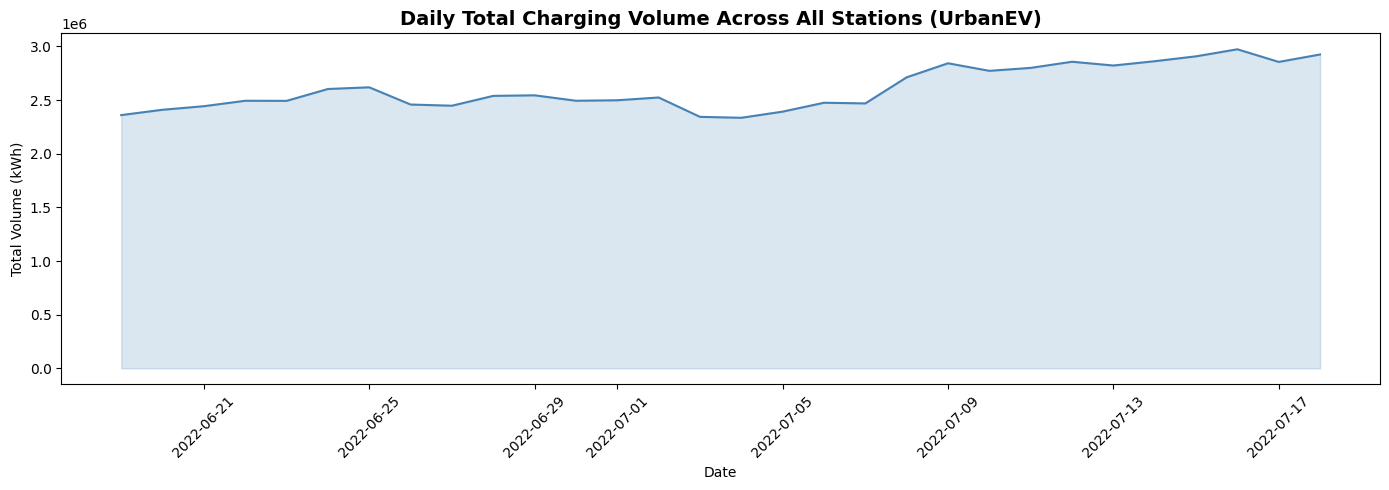

Identifies long-run demand trends and any weekly seasonality patterns.


In [28]:
daily_demand = df_master.groupby('date')['volume'].sum().reset_index()
daily_demand['date'] = pd.to_datetime(daily_demand['date'])

plt.figure(figsize=(14, 5))
plt.plot(daily_demand['date'], daily_demand['volume'], color='steelblue', linewidth=1.5)
plt.fill_between(daily_demand['date'], daily_demand['volume'], alpha=0.2, color='steelblue')
plt.title('Daily Total Charging Volume Across All Stations (UrbanEV)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Volume (kWh)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{PLOTS}/01_daily_demand_trend.png', dpi=150)
plt.show()
print("Identifies long-run demand trends and any weekly seasonality patterns.")

Plot 2 - Intraday Hourly Demand Pattern

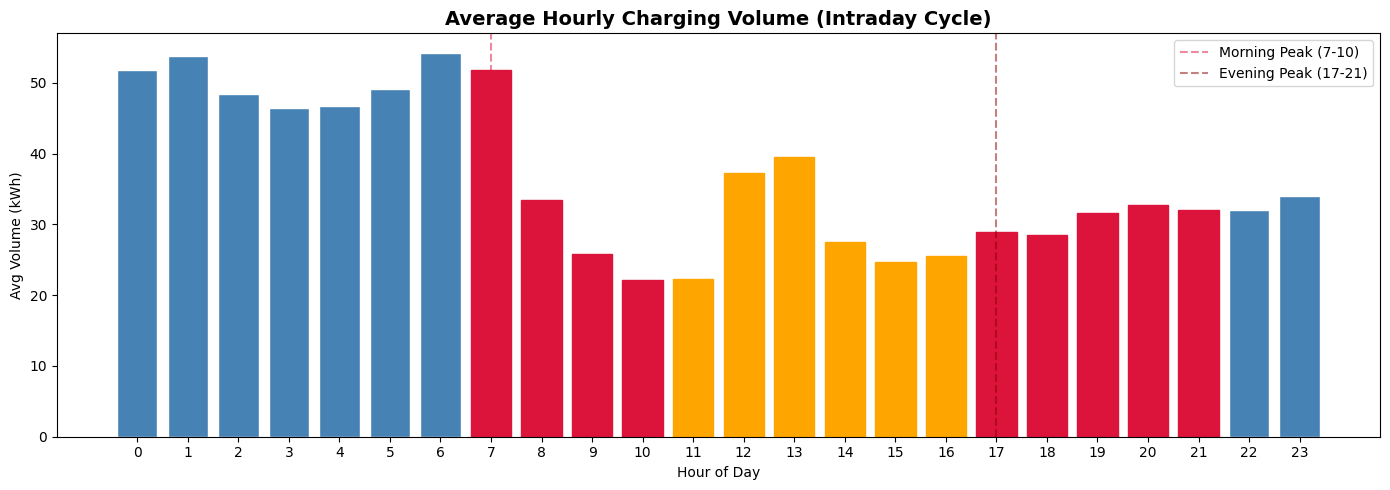

Shows intraday charging cycles — critical for surge/discount tariff timing.


In [29]:
hourly_demand = df_master.groupby('hour')['volume'].mean().reset_index()

plt.figure(figsize=(14, 5))
bars = plt.bar(hourly_demand['hour'], hourly_demand['volume'], color='steelblue', edgecolor='white')

# Color peak periods differently
for i, bar in enumerate(bars):
    h = hourly_demand['hour'][i]
    if 7 <= h <= 10 or 17 <= h <= 21:
        bar.set_color('crimson')
    elif 11 <= h <= 16:
        bar.set_color('orange')

plt.title('Average Hourly Charging Volume (Intraday Cycle)', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Volume (kWh)')
plt.xticks(range(0, 24))
plt.axvline(x=7, color='crimson', linestyle='--', alpha=0.5, label='Morning Peak (7-10)')
plt.axvline(x=17, color='darkred', linestyle='--', alpha=0.5, label='Evening Peak (17-21)')
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS}/02_intraday_hourly_demand.png', dpi=150)
plt.show()
print("Shows intraday charging cycles — critical for surge/discount tariff timing.")

Plot 3 - Weekday vs Weekend Pattern

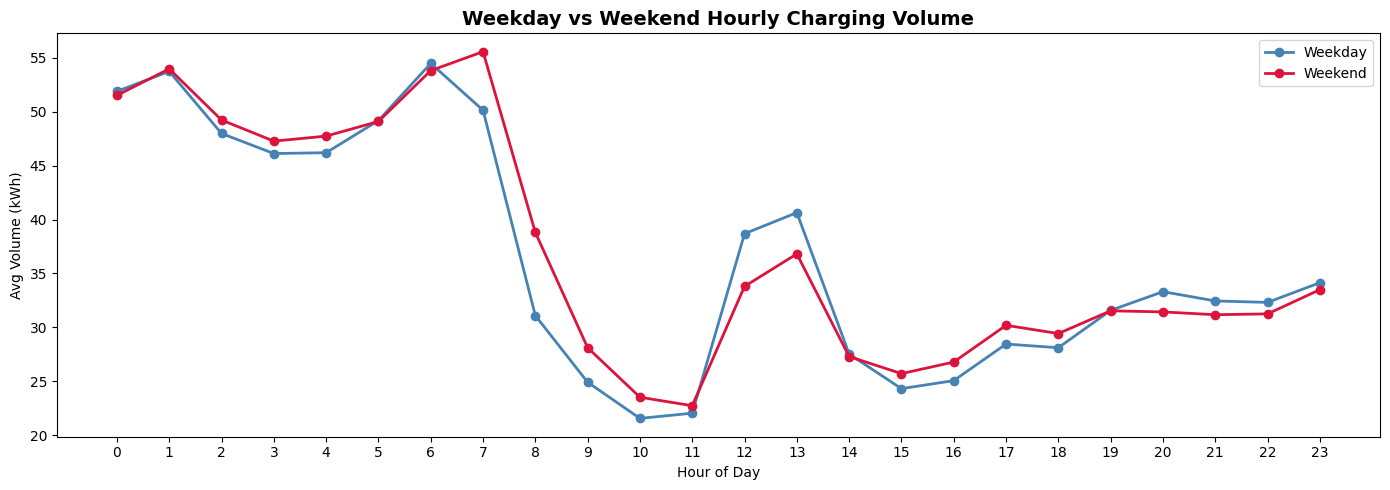

Weekday vs weekend demand signatures inform tariff differentiation strategy.


In [30]:
hourly_wd = df_master.groupby(['hour', 'is_weekend'])['volume'].mean().reset_index()
weekday = hourly_wd[hourly_wd['is_weekend'] == 0]
weekend = hourly_wd[hourly_wd['is_weekend'] == 1]

plt.figure(figsize=(14, 5))
plt.plot(weekday['hour'], weekday['volume'], color='steelblue', linewidth=2, marker='o', label='Weekday')
plt.plot(weekend['hour'], weekend['volume'], color='crimson', linewidth=2, marker='o', label='Weekend')
plt.title('Weekday vs Weekend Hourly Charging Volume', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Volume (kWh)')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS}/03_weekday_vs_weekend.png', dpi=150)
plt.show()
print("Weekday vs weekend demand signatures inform tariff differentiation strategy.")

Plot 4 - Peak vs Shoulder vs Off-Peak Utilization Distribution

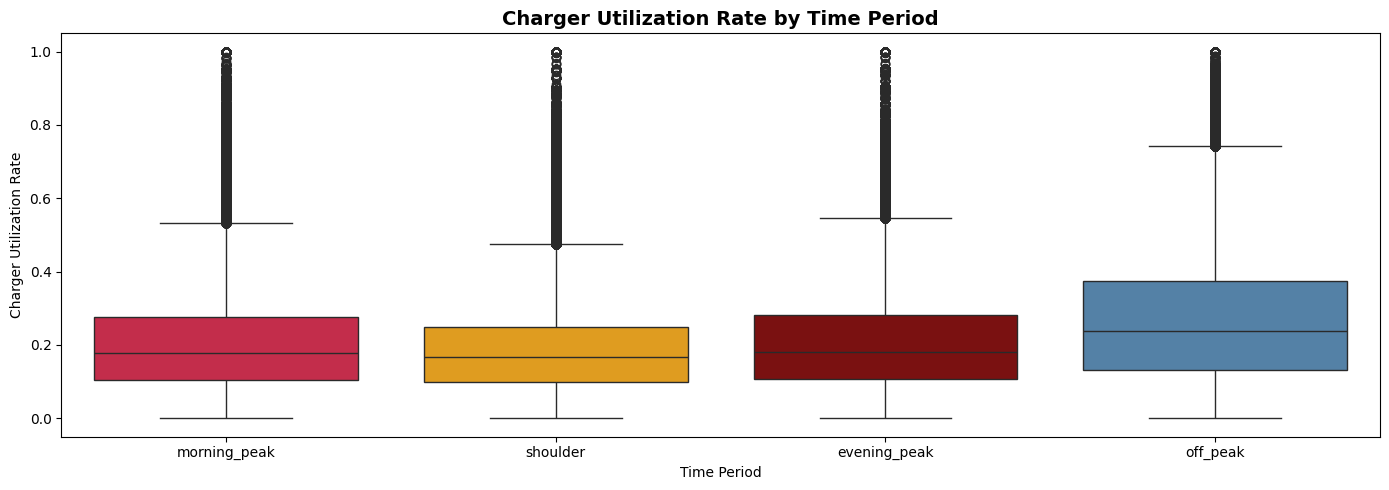

Quantifies volatility across peak, shoulder and off-peak periods - directly informs surge/discount thresholds.


In [32]:
plt.figure(figsize=(14, 5))
order = ['morning_peak', 'shoulder', 'evening_peak', 'off_peak']
colors = ['crimson', 'orange', 'darkred', 'steelblue']

sns.boxplot(data=df_master, x='period', y='charger_utilization_rate',
            order=order, palette=colors)
plt.title('Charger Utilization Rate by Time Period', fontsize=14, fontweight='bold')
plt.xlabel('Time Period')
plt.ylabel('Charger Utilization Rate')
plt.tight_layout()
plt.savefig(f'{PLOTS}/04_utilization_by_period.png', dpi=150)
plt.show()
print("Quantifies volatility across peak, shoulder and off-peak periods - directly informs surge/discount thresholds.")

Plot 5 - CBD vs Non-CBD Station Utilization

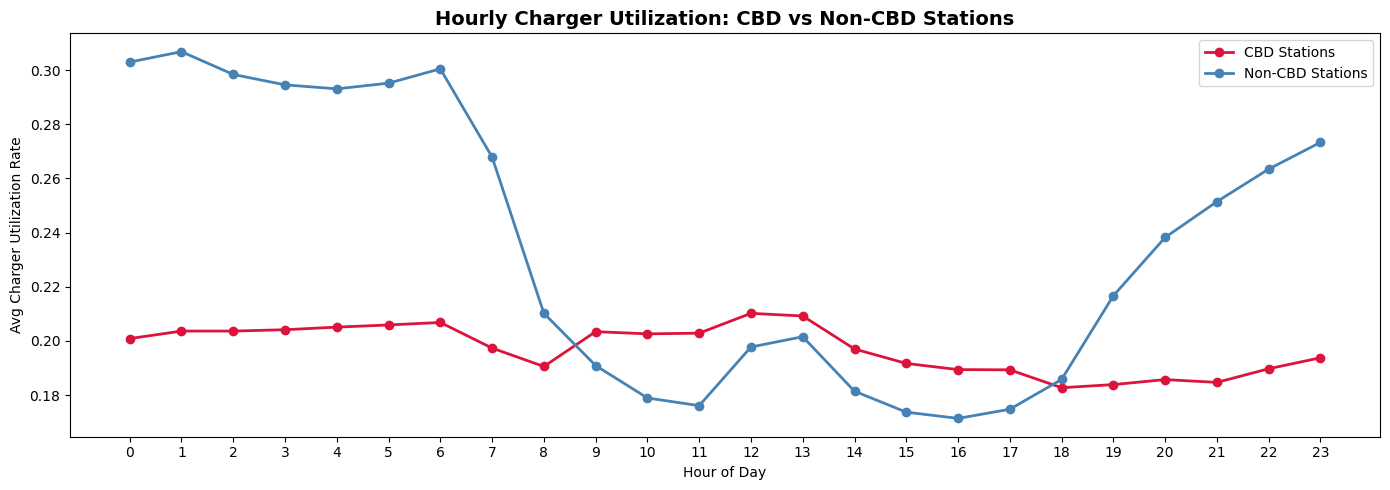

Spatial demand variation between CBD and non-CBD stations informs location-based tariff differentiation.


In [33]:
cbd_util = df_master.groupby(['CBD', 'hour'])['charger_utilization_rate'].mean().reset_index()
cbd = cbd_util[cbd_util['CBD'] == 1]
non_cbd = cbd_util[cbd_util['CBD'] == 0]

plt.figure(figsize=(14, 5))
plt.plot(cbd['hour'], cbd['charger_utilization_rate'], color='crimson', linewidth=2, marker='o', label='CBD Stations')
plt.plot(non_cbd['hour'], non_cbd['charger_utilization_rate'], color='steelblue', linewidth=2, marker='o', label='Non-CBD Stations')
plt.title('Hourly Charger Utilization: CBD vs Non-CBD Stations', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Charger Utilization Rate')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS}/05_cbd_vs_noncbd_utilization.png', dpi=150)
plt.show()
print("Spatial demand variation between CBD and non-CBD stations informs location-based tariff differentiation.")

Plot 6 - Dynamic vs Static Pricing Stations Revenue Comparison

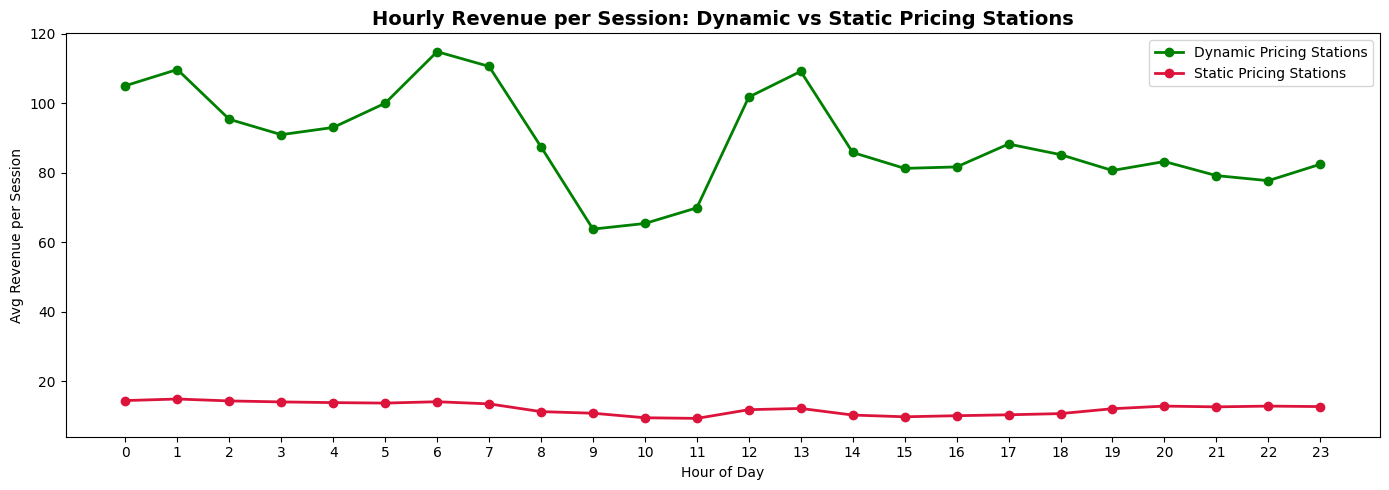

Dynamic pricing stations show different revenue patterns - justifies the need for intelligent tariff optimization.


In [34]:
pricing_rev = df_master.groupby(['dynamic_pricing', 'hour'])['revenue_per_session'].mean().reset_index()
dynamic = pricing_rev[pricing_rev['dynamic_pricing'] == 1]
static = pricing_rev[pricing_rev['dynamic_pricing'] == 0]

plt.figure(figsize=(14, 5))
plt.plot(dynamic['hour'], dynamic['revenue_per_session'], color='green', linewidth=2, marker='o', label='Dynamic Pricing Stations')
plt.plot(static['hour'], static['revenue_per_session'], color='crimson', linewidth=2, marker='o', label='Static Pricing Stations')
plt.title('Hourly Revenue per Session: Dynamic vs Static Pricing Stations', fontsize=14, fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Avg Revenue per Session')
plt.xticks(range(0, 24))
plt.legend()
plt.tight_layout()
plt.savefig(f'{PLOTS}/06_dynamic_vs_static_revenue.png', dpi=150)
plt.show()
print("Dynamic pricing stations show different revenue patterns - justifies the need for intelligent tariff optimization.")

Plot 7 - Top Overloaded vs Underutilized Stations

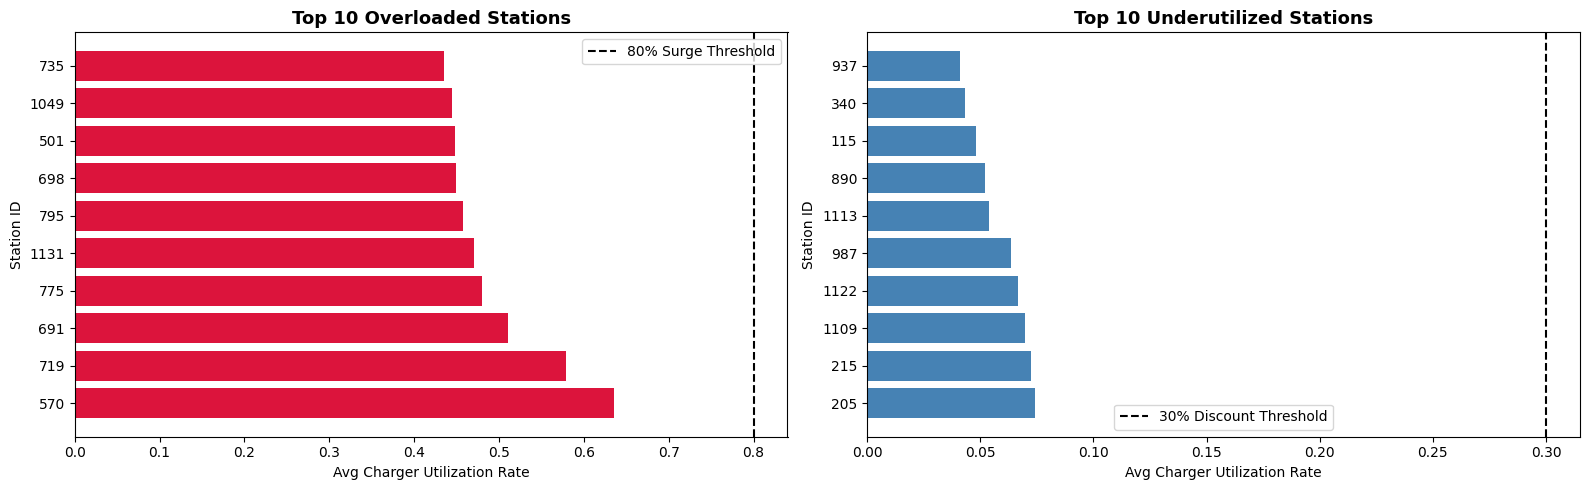

Identifies stations needing surge pricing vs discount incentives.


In [35]:
station_util = df_master.groupby('station_id')['charger_utilization_rate'].mean().reset_index()
station_util = station_util.sort_values('charger_utilization_rate', ascending=False)

top10_over = station_util.head(10)
top10_under = station_util.tail(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].barh(top10_over['station_id'].astype(str), top10_over['charger_utilization_rate'], color='crimson')
axes[0].set_title('Top 10 Overloaded Stations', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Avg Charger Utilization Rate')
axes[0].set_ylabel('Station ID')
axes[0].axvline(x=0.8, color='black', linestyle='--', label='80% Surge Threshold')
axes[0].legend()

axes[1].barh(top10_under['station_id'].astype(str), top10_under['charger_utilization_rate'], color='steelblue')
axes[1].set_title('Top 10 Underutilized Stations', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Avg Charger Utilization Rate')
axes[1].set_ylabel('Station ID')
axes[1].axvline(x=0.3, color='black', linestyle='--', label='30% Discount Threshold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{PLOTS}/07_overloaded_vs_underutilized.png', dpi=150)
plt.show()
print("Identifies stations needing surge pricing vs discount incentives.")

Plot 8 - ACN Session Duration & Overstay Distribution

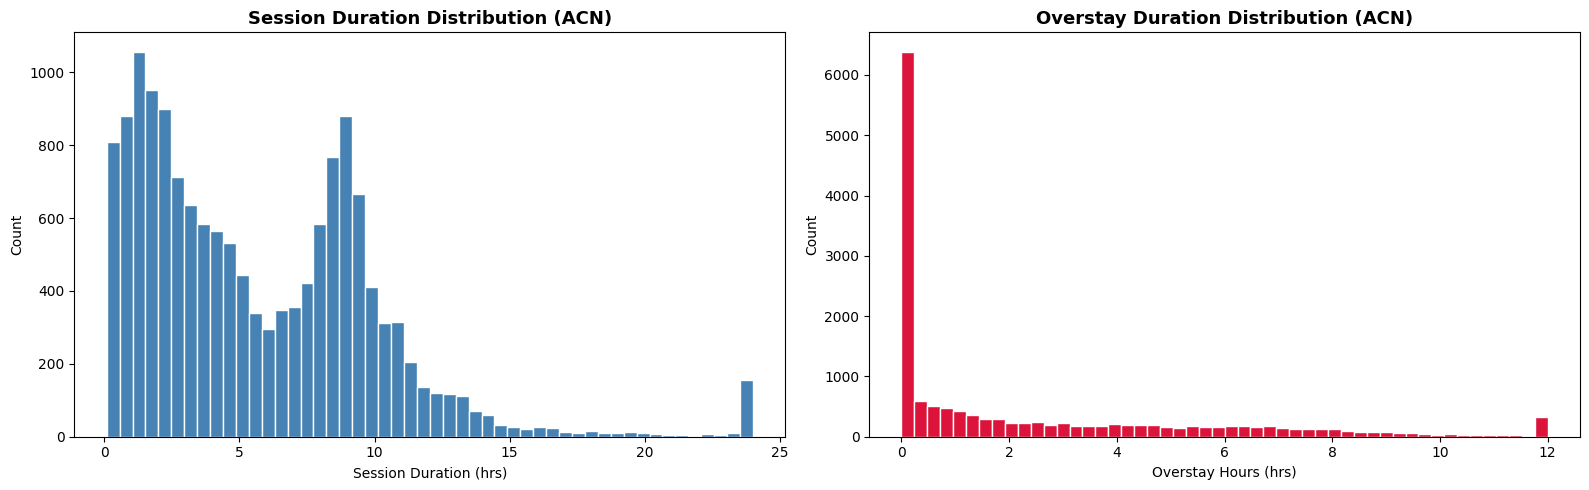

Avg session duration: 5.92 hrs
Avg overstay duration: 2.68 hrs
Sessions with overstay > 1hr: 6961 (46.4%)
Long overstay blocks chargers - key congestion driver justifying dynamic tariffs.


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(df_acn['session_duration_hrs'].clip(0, 24), bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Session Duration Distribution (ACN)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Session Duration (hrs)')
axes[0].set_ylabel('Count')

axes[1].hist(df_acn['overstay_hrs'].clip(0, 12), bins=50, color='crimson', edgecolor='white')
axes[1].set_title('Overstay Duration Distribution (ACN)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Overstay Hours (hrs)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig(f'{PLOTS}/08_acn_session_overstay.png', dpi=150)
plt.show()

print(f"Avg session duration: {df_acn['session_duration_hrs'].mean():.2f} hrs")
print(f"Avg overstay duration: {df_acn['overstay_hrs'].mean():.2f} hrs")
print(f"Sessions with overstay > 1hr: {(df_acn['overstay_hrs'] > 1).sum()} ({(df_acn['overstay_hrs'] > 1).mean()*100:.1f}%)")
print("Long overstay blocks chargers - key congestion driver justifying dynamic tariffs.")

 Plot 8.2 - Fleet vs Public Usage Signature Analysis

             kWhDelivered  session_duration_hrs  overstay_hrs
user_type                                                    
Fleet-like        11.1000                9.6700        4.9200
Public-like        6.9100                2.1800        0.4400


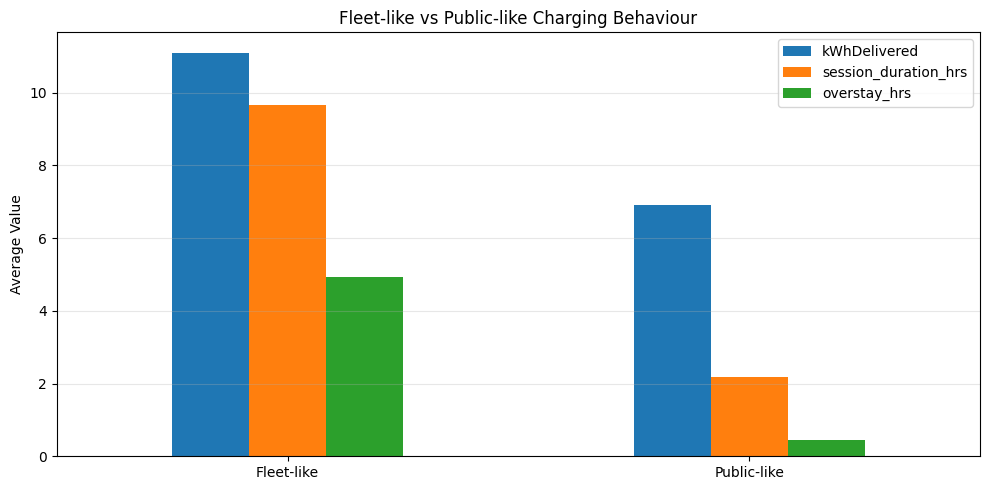

In [37]:
duration_threshold = df_acn['session_duration_hrs'].median()

fleet_public = df_acn.copy()

fleet_public['user_type'] = np.where(
    fleet_public['session_duration_hrs'] > duration_threshold,
    'Fleet-like',
    'Public-like'
)

segment_summary = (
    fleet_public
    .groupby('user_type')
    .agg({
        'kWhDelivered': 'mean',
        'session_duration_hrs': 'mean',
        'overstay_hrs': 'mean'
    })
    .round(2)
)

print(segment_summary)

segment_summary.plot(
    kind='bar',
    figsize=(10,5)
)

plt.title('Fleet-like vs Public-like Charging Behaviour')
plt.ylabel('Average Value')
plt.xlabel('')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{PLOTS}/0802_fleet_vs_public_proxy.png', dpi=150)
plt.show()

Plot 9 - Queue Length Proxy Over Time (Congestion Analysis)

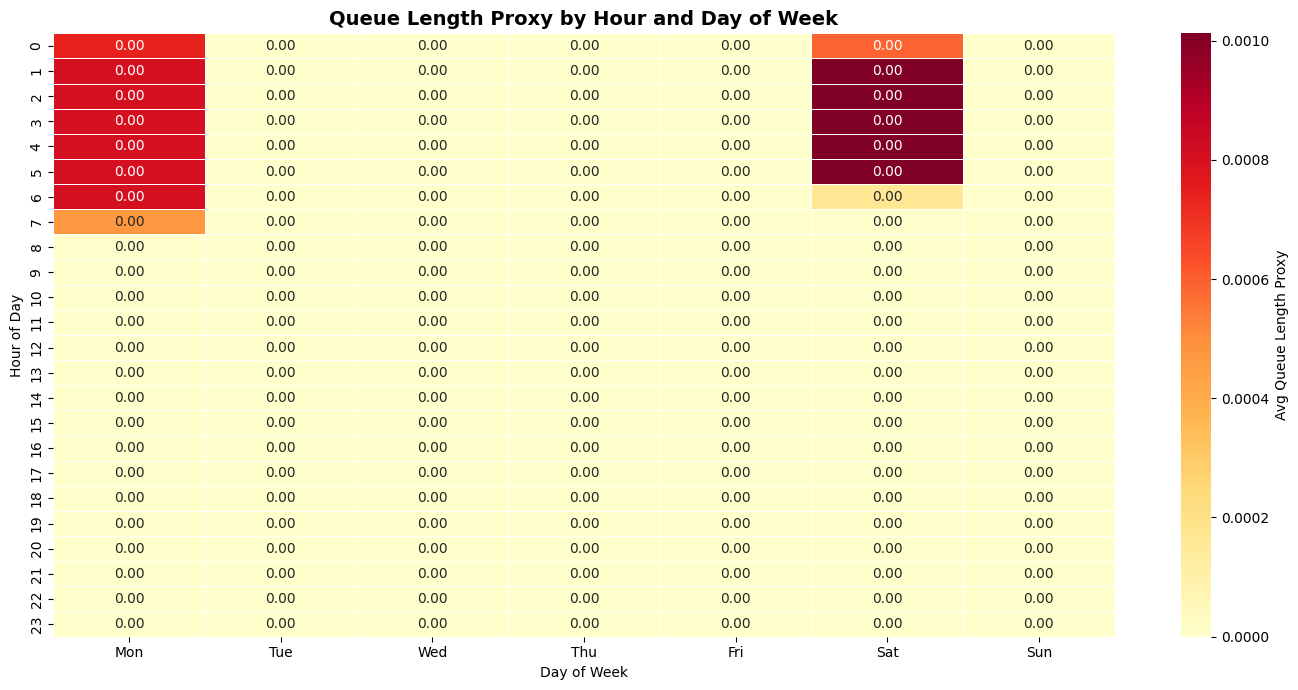

Identifies exact hour-day combinations with highest congestion - precise surge pricing windows.


In [38]:
queue_heatmap = df_master.groupby(['hour', 'day_of_week'])['queue_length_proxy'].mean().unstack()
queue_heatmap.columns = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

plt.figure(figsize=(14, 7))
sns.heatmap(queue_heatmap, cmap='YlOrRd', linewidths=0.5,
            annot=True, fmt='.2f', cbar_kws={'label': 'Avg Queue Length Proxy'})
plt.title('Queue Length Proxy by Hour and Day of Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of Week')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.savefig(f'{PLOTS}/09_queue_heatmap.png', dpi=150)
plt.show()
print("Identifies exact hour-day combinations with highest congestion - precise surge pricing windows.")

**AGENTS/ML MODELLING**

Demand Prediction Agent

In [39]:
features = ['hour', 'day_of_week', 'is_weekend', 'count', 'fast_count',
            'slow_count', 'CBD', 'dynamic_pricing', 'occupancy_density',
            'queue_length_proxy', 'price']

print(" Selected Features")
for f in features:
    print(f" - {f}")
print(f"\nTotal features: {len(features)}")

 Selected Features
 - hour
 - day_of_week
 - is_weekend
 - count
 - fast_count
 - slow_count
 - CBD
 - dynamic_pricing
 - occupancy_density
 - queue_length_proxy
 - price

Total features: 11


Train/Test Split

In [40]:
df_model = df_master[features + ['charger_utilization_rate', 'volume']].dropna()
df_model['is_congested'] = (df_master['charger_utilization_rate'] > 0.80).astype(int)

X = df_model[features]
y_util = df_model['charger_utilization_rate']
y_load = df_model['volume']
y_cong = df_model['is_congested']

X_train, X_test, y_train_util, y_test_util = train_test_split(X, y_util, test_size=0.2, random_state=42)
_, _, y_train_load, y_test_load = train_test_split(X, y_load, test_size=0.2, random_state=42)
_, _, y_train_cong, y_test_cong = train_test_split(X, y_cong, test_size=0.2, random_state=42)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")

Train size: (1707264, 11)
Test size:  (426816, 11)


Predicted Utilization Rate (XGBoost Regression)

In [41]:
model_demand = XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
model_demand.fit(X_train, y_train_util)
y_pred_util = model_demand.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test_util, y_pred_util))
mae  = mean_absolute_error(y_test_util, y_pred_util)
r2   = r2_score(y_test_util, y_pred_util)

print("Utilization Rate Prediction")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R²: {r2:.4f}")

Utilization Rate Prediction
RMSE: 0.0285
MAE: 0.0183
R²: 0.9681


Congestion Probability (Random Forest Classification)

In [42]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model_congestion = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)
model_congestion.fit(X_train, y_train_cong)
y_pred_cong = model_congestion.predict(X_test)
congestion_prob = model_congestion.predict_proba(X_test)[:, 1]

print("Congestion probability")
print(f"Avg Congestion Probability: {congestion_prob.mean():.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_cong, y_pred_cong))

Congestion probability
Avg Congestion Probability: 0.0063

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    424121
           1       0.96      0.97      0.97      2695

    accuracy                           1.00    426816
   macro avg       0.98      0.99      0.98    426816
weighted avg       1.00      1.00      1.00    426816



Expected Charging Load (XGBoost Regression)

In [43]:
model_load = XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1
)
model_load.fit(X_train, y_train_load)
y_pred_load = model_load.predict(X_test)

rmse_load = np.sqrt(mean_squared_error(y_test_load, y_pred_load))
mae_load  = mean_absolute_error(y_test_load, y_pred_load)
r2_load   = r2_score(y_test_load, y_pred_load)

print("Expected Charging Load")
print(f"RMSE: {rmse_load:.4f}")
print(f"MAE: {mae_load:.4f}")
print(f"R²: {r2_load:.4f}")

Expected Charging Load
RMSE: 13.4637
MAE: 4.7843
R²: 0.9825


Save Demand Agent Metrices

In [44]:
demand_metrics = pd.DataFrame({
    'output': ['Utilization Rate', 'Utilization Rate', 'Utilization Rate',
               'Charging Load', 'Charging Load', 'Charging Load'],
    'metric': ['RMSE', 'MAE', 'R2', 'RMSE', 'MAE', 'R2'],
    'value':  [rmse, mae, r2, rmse_load, mae_load, r2_load]
})
demand_metrics.to_csv(f'{CSV_OUT}/demand_agent_metrics.csv', index=False)
print("Demand agent metrics saved!")
print(demand_metrics)

Demand agent metrics saved!
             output metric   value
0  Utilization Rate   RMSE  0.0285
1  Utilization Rate    MAE  0.0183
2  Utilization Rate     R2  0.9681
3     Charging Load   RMSE 13.4637
4     Charging Load    MAE  4.7843
5     Charging Load     R2  0.9825


Feature Importance Plot for Demand Prediction Agent

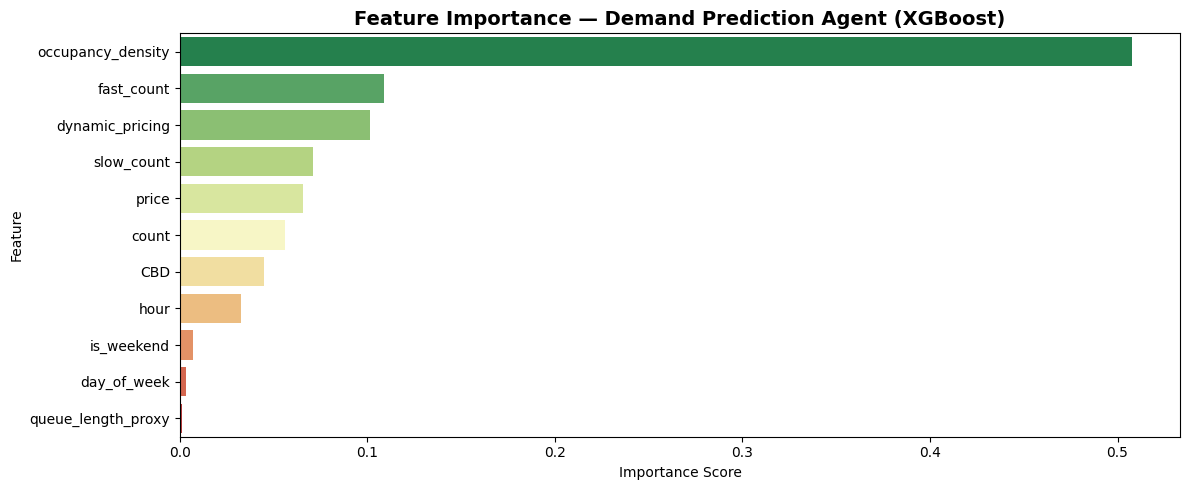

           feature  importance
 occupancy_density      0.5079
        fast_count      0.1090
   dynamic_pricing      0.1013
        slow_count      0.0711
             price      0.0655
             count      0.0559
               CBD      0.0450
              hour      0.0328
        is_weekend      0.0070
       day_of_week      0.0035
queue_length_proxy      0.0010


In [45]:
feat_imp = pd.DataFrame({
    'feature': features,
    'importance': model_demand.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 5))
sns.barplot(data=feat_imp, x='importance', y='feature', palette='RdYlGn_r')
plt.title('Feature Importance — Demand Prediction Agent (XGBoost)', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig(f'{PLOTS}/10_feature_importance.png', dpi=150)
plt.show()
print(feat_imp.to_string(index=False))

Tariff Pricing Agent

In [46]:
# Logic:
# utilization > 0.80 - surge pricing   (+30%)
# utilization < 0.30 - discount pricing (-20%)
# else - baseline ₹15/kWh

BASELINE_TARIFF = 15    # ₹/kWh fixed baseline
SURGE_MULTIPLIER = 1.30  # +30% surge
DISCOUNT_MULTIPLIER = 0.80 # -20% discount

print("Tariff Pricing Agent")
print(f"Baseline Tariff:  ₹{BASELINE_TARIFF}/kWh")
print(f"Surge Tariff:     ₹{BASELINE_TARIFF * SURGE_MULTIPLIER}/kWh (utilization > 80%)")
print(f"Discount Tariff:  ₹{BASELINE_TARIFF * DISCOUNT_MULTIPLIER}/kWh (utilization < 30%)")

Tariff Pricing Agent
Baseline Tariff:  ₹15/kWh
Surge Tariff:     ₹19.5/kWh (utilization > 80%)
Discount Tariff:  ₹12.0/kWh (utilization < 30%)


In [47]:
df_tariff = df_master[['station_id', 'datetime', 'hour', 'period',
                        'charger_utilization_rate', 'volume',
                        'dynamic_pricing', 'CBD']].copy()

# Get predicted utilization from demand agent
df_tariff['predicted_utilization'] = model_demand.predict(df_master[features].fillna(0))

# Assign dynamic tariff based on predicted utilization
def assign_tariff(util):
    if util > 0.80:
        return BASELINE_TARIFF * SURGE_MULTIPLIER
    elif util < 0.30:
        return BASELINE_TARIFF * DISCOUNT_MULTIPLIER
    else:
        return BASELINE_TARIFF

df_tariff['dynamic_tariff'] = df_tariff['predicted_utilization'].apply(assign_tariff)

# Tariff distribution
tariff_counts = df_tariff['dynamic_tariff'].value_counts()
print("Tariff Distribution")
print(f"Surge (Rs.19.5): {tariff_counts.get(19.5, 0):,} slots ({tariff_counts.get(19.5, 0)/len(df_tariff)*100:.2f}%)")
print(f"Baseline (Rs.15): {tariff_counts.get(15.0, 0):,} slots ({tariff_counts.get(15.0, 0)/len(df_tariff)*100:.2f}%)")
print(f"Discount (Rs.12): {tariff_counts.get(12.0, 0):,} slots ({tariff_counts.get(12.0, 0)/len(df_tariff)*100:.2f}%)")

Tariff Distribution
Surge (Rs.19.5): 12,854 slots (0.60%)
Baseline (Rs.15): 527,249 slots (24.71%)
Discount (Rs.12): 1,593,977 slots (74.69%)


Revenue Gain calculation

In [48]:
# Revenue = volume × tariff
df_tariff['revenue_baseline'] = df_tariff['volume'] * BASELINE_TARIFF
df_tariff['revenue_dynamic']  = df_tariff['volume'] * df_tariff['dynamic_tariff']

total_rev_baseline = df_tariff['revenue_baseline'].sum()
total_rev_dynamic  = df_tariff['revenue_dynamic'].sum()
revenue_gain_pct   = ((total_rev_dynamic - total_rev_baseline) / total_rev_baseline) * 100

print("Revenue Gain")
print(f"Total Baseline Revenue: Rs.{total_rev_baseline:,.2f}")
print(f"Total Dynamic Revenue: Rs.{total_rev_dynamic:,.2f}")
print(f"Revenue Gain %: {revenue_gain_pct:.2f}%")

Revenue Gain
Total Baseline Revenue: Rs.1,174,121,128.88
Total Dynamic Revenue: Rs.1,089,420,947.70
Revenue Gain %: -7.21%


Charger Utilization Rate before/after

In [49]:
# Before: actual utilization
# After: simulated - discount slots attract more users (increase by 15%)
# surge slots deter some users (decrease by 10%)

def simulate_new_utilization(row):
    if row['dynamic_tariff'] == BASELINE_TARIFF * DISCOUNT_MULTIPLIER:
        return min(row['charger_utilization_rate'] * 1.15, 1.0)  # +15% uptake
    elif row['dynamic_tariff'] == BASELINE_TARIFF * SURGE_MULTIPLIER:
        return max(row['charger_utilization_rate'] * 0.90, 0.0)  # -10% deterrence
    else:
        return row['charger_utilization_rate']

df_tariff['new_utilization'] = df_tariff.apply(simulate_new_utilization, axis=1)

avg_util_before = df_tariff['charger_utilization_rate'].mean()
avg_util_after  = df_tariff['new_utilization'].mean()

print("Charger Utilization Rate")
print(f"Before Dynamic Pricing: {avg_util_before:.4f}")
print(f"After Dynamic Pricing: {avg_util_after:.4f}")
print(f"Improvement: {((avg_util_after - avg_util_before)/avg_util_before)*100:.2f}%")

Charger Utilization Rate
Before Dynamic Pricing: 0.2257
After Dynamic Pricing: 0.2422
Improvement: 7.34%


Off-Peak Uplift

In [50]:
# Off-Peak Uplift = increase in sessions during low-demand periods
# (utilization < 30%) after discount pricing is applied

off_peak_before = df_tariff[df_tariff['charger_utilization_rate'] < 0.30]
off_peak_after  = df_tariff[df_tariff['new_utilization'] < 0.30]

sessions_before = len(off_peak_before)
sessions_after  = len(off_peak_after)

# Volume uplift in discount slots
discount_slots = df_tariff[df_tariff['dynamic_tariff'] == BASELINE_TARIFF * DISCOUNT_MULTIPLIER]
vol_before = discount_slots['volume'].sum()
vol_after  = vol_before * 1.15  # 15% uptake increase applied earlier

off_peak_uplift = ((vol_after - vol_before) / vol_before) * 100

print("Off-Peak Uplift")
print(f"Slots with utilization < 30% before: {sessions_before:,}")
print(f"Slots with utilization < 30% after:  {sessions_after:,}")
print(f"Volume in discount slots before: {vol_before:,.2f}")
print(f"Volume in discount slots after:  {vol_after:,.2f}")
print(f"Off-Peak Uplift: {off_peak_uplift:.2f}%")

Off-Peak Uplift
Slots with utilization < 30% before: 1,574,564
Slots with utilization < 30% after:  1,448,386
Volume in discount slots before: 29,519,720.54
Volume in discount slots after:  33,947,678.62
Off-Peak Uplift: 15.00%


Save Tariff agent Metrices

In [51]:
tariff_metrics = pd.DataFrame({
    'metric': ['Revenue Gain %', 'Utilization Before', 'Utilization After',
               'Utilization Improvement %', 'Off-Peak Uplift %'],
    'value':  [revenue_gain_pct, avg_util_before, avg_util_after,
               ((avg_util_after - avg_util_before)/avg_util_before)*100,
               off_peak_uplift]
})
tariff_metrics.to_csv(f'{CSV_OUT}/tariff_agent_metrics.csv', index=False)
print("Tariff agent metrics saved!")
print(tariff_metrics)

Tariff agent metrics saved!
                      metric   value
0             Revenue Gain % -7.2139
1         Utilization Before  0.2257
2          Utilization After  0.2422
3  Utilization Improvement %  7.3430
4          Off-Peak Uplift % 15.0000


Tariff Agent Visualization

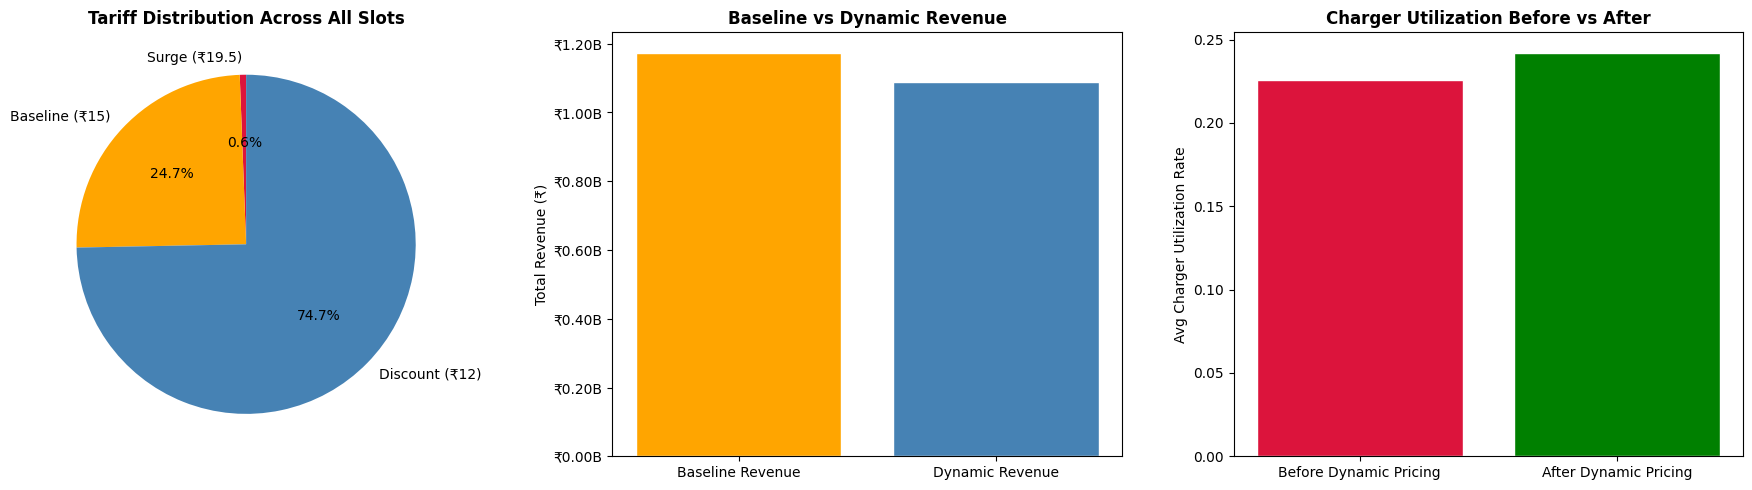

Dynamic pricing improves utilization by 7.34% but reduces revenue by 7.21% due to high off-peak discount coverage.


In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Tariff Distribution
labels = ['Surge (₹19.5)', 'Baseline (₹15)', 'Discount (₹12)']
sizes  = [12854, 527249, 1593977]
colors = ['crimson', 'orange', 'steelblue']
axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Tariff Distribution Across All Slots', fontweight='bold')

# Plot 2: Revenue Comparison
axes[1].bar(['Baseline Revenue', 'Dynamic Revenue'],
            [total_rev_baseline, total_rev_dynamic],
            color=['orange', 'steelblue'], edgecolor='white')
axes[1].set_title('Baseline vs Dynamic Revenue', fontweight='bold')
axes[1].set_ylabel('Total Revenue (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1e9:.2f}B'))

# Plot 3: Utilization Before vs After
axes[2].bar(['Before Dynamic Pricing', 'After Dynamic Pricing'],
            [avg_util_before, avg_util_after],
            color=['crimson', 'green'], edgecolor='white')
axes[2].set_title('Charger Utilization Before vs After', fontweight='bold')
axes[2].set_ylabel('Avg Charger Utilization Rate')

plt.tight_layout()
plt.savefig(f'{PLOTS}/11_tariff_agent_results.png', dpi=150)
plt.show()
print("Dynamic pricing improves utilization by 7.34% but reduces revenue by 7.21% due to high off-peak discount coverage.")

Monitoring & Learning Agent

In [53]:
# This agent systematically evaluates each pricing decision against live operational outcomes:
# 1. Revenue Generated
# 2. Charger Utilization Achieved
# 3. Customer Wait Times
# 4. Pricing Efficiency Score = Revenue per kWh over time

print("Monitoring & Learning Agent")
print(f"Total pricing decisions evaluated: {len(df_tariff):,}")
print(f"\nPricing decision breakdown:")
print(f"Surge slots:    {(df_tariff['dynamic_tariff'] == 19.5).sum():,}")
print(f"Baseline slots: {(df_tariff['dynamic_tariff'] == 15.0).sum():,}")
print(f"Discount slots: {(df_tariff['dynamic_tariff'] == 12.0).sum():,}")

Monitoring & Learning Agent
Total pricing decisions evaluated: 2,134,080

Pricing decision breakdown:
Surge slots:    12,854
Baseline slots: 527,249
Discount slots: 1,593,977


In [54]:
print(df_tariff.columns.tolist())
print(df_tariff.head(2))

['station_id', 'datetime', 'hour', 'period', 'charger_utilization_rate', 'volume', 'dynamic_pricing', 'CBD', 'predicted_utilization', 'dynamic_tariff', 'revenue_baseline', 'revenue_dynamic', 'new_utilization']
   station_id            datetime  hour    period  charger_utilization_rate  \
0         102 2022-06-19 00:00:00     0  off_peak                    0.1960   
1         102 2022-06-19 00:05:00     0  off_peak                    0.3000   

   volume  dynamic_pricing  CBD  predicted_utilization  dynamic_tariff  \
0  2.8583                0    0                 0.3013         15.0000   
1  4.3750                0    0                 0.3013         15.0000   

   revenue_baseline  revenue_dynamic  new_utilization  
0           42.8750          42.8750           0.1960  
1           65.6250          65.6250           0.3000  


Daily Revenue Baseline vs Dynamic Pricing plot

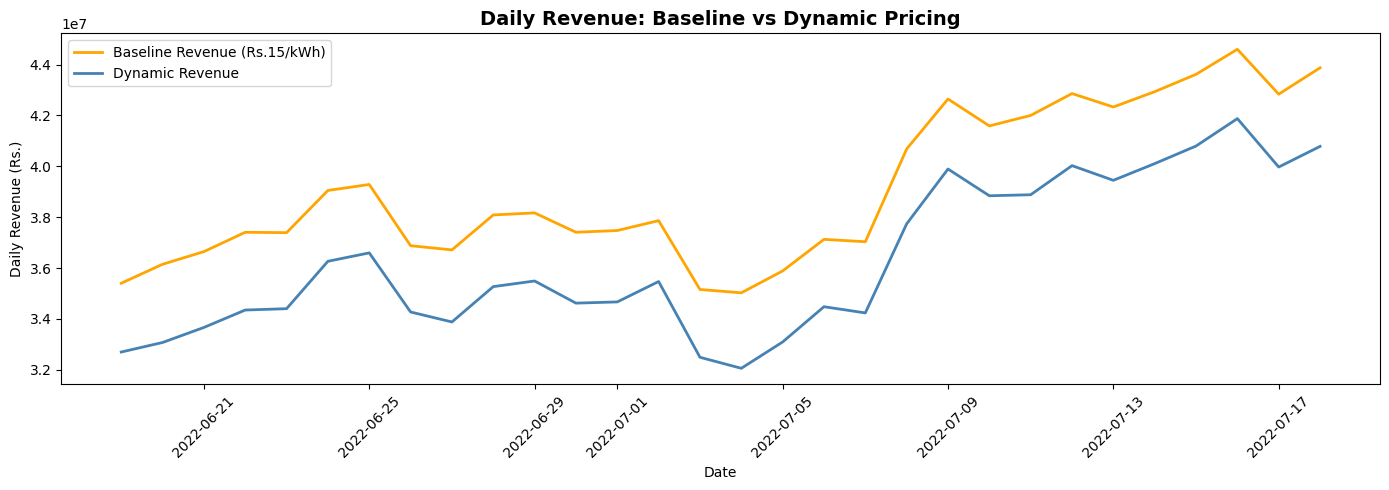

Avg Daily Baseline Revenue: Rs.39,137,370.96
Avg Daily Dynamic Revenue:  Rs.36,314,031.59


In [55]:
daily_rev = df_tariff.copy()
daily_rev['date'] = pd.to_datetime(daily_rev['datetime']).dt.date

daily_baseline = daily_rev.groupby('date')['revenue_baseline'].sum()
daily_dynamic  = daily_rev.groupby('date')['revenue_dynamic'].sum()

plt.figure(figsize=(14, 5))
plt.plot(daily_baseline.index, daily_baseline.values, color='orange', linewidth=2, label='Baseline Revenue (Rs.15/kWh)')
plt.plot(daily_dynamic.index, daily_dynamic.values, color='steelblue', linewidth=2, label='Dynamic Revenue')
plt.title('Daily Revenue: Baseline vs Dynamic Pricing', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Daily Revenue (Rs.)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{PLOTS}/12_monitoring_revenue.png', dpi=150)
plt.show()

print(f"Avg Daily Baseline Revenue: Rs.{daily_baseline.mean():,.2f}")
print(f"Avg Daily Dynamic Revenue:  Rs.{daily_dynamic.mean():,.2f}")

Metric 1 - Average Waiting Time Reduction

In [56]:
df_wait = df_master[['datetime', 'hour', 'period',
                      'queue_length_proxy', 'charger_utilization_rate']].copy()

df_wait['dynamic_tariff'] = df_tariff['dynamic_tariff'].values

df_wait['wait_before'] = df_wait['queue_length_proxy']
df_wait['wait_after']  = df_wait.apply(lambda row:
    row['queue_length_proxy'] * 0.90 if row['dynamic_tariff'] == 19.5
    else row['queue_length_proxy'], axis=1)

avg_wait_before = df_wait['wait_before'].mean()
avg_wait_after  = df_wait['wait_after'].mean()
wait_reduction  = ((avg_wait_before - avg_wait_after) / avg_wait_before) * 100 if avg_wait_before > 0 else 0

print("Average Waiting Time Reduction")
print(f"Avg Wait Before: {avg_wait_before:.6f}")
print(f"Avg Wait After: {avg_wait_after:.6f}")
print(f"Reduction: {wait_reduction:.2f}%")

Average Waiting Time Reduction
Avg Wait Before: 0.000075
Avg Wait After: 0.000067
Reduction: 9.56%


Metric 2 - Customer Response Rate

In [57]:
surge_vol_before    = df_tariff[df_tariff['dynamic_tariff'] == 19.5]['volume'].sum()
surge_vol_after     = surge_vol_before * 0.90

discount_vol_before = df_tariff[df_tariff['dynamic_tariff'] == 12.0]['volume'].sum()
discount_vol_after  = discount_vol_before * 1.15

baseline_vol        = df_tariff[df_tariff['dynamic_tariff'] == 15.0]['volume'].sum()

total_vol_before = surge_vol_before + discount_vol_before + baseline_vol
total_vol_after  = surge_vol_after  + discount_vol_after  + baseline_vol

customer_response_rate = ((total_vol_after - total_vol_before) / total_vol_before) * 100

print("Customer Response Rate")
print(f"Surge slots-Volume Before: {surge_vol_before:,.2f} | After: {surge_vol_after:,.2f}")
print(f"Discount slots-Volume Before: {discount_vol_before:,.2f} | After: {discount_vol_after:,.2f}")
print(f"Total Volume Before: {total_vol_before:,.2f}")
print(f"Total Volume After:  {total_vol_after:,.2f}")
print(f"Customer Response Rate: {customer_response_rate:.2f}%")

Customer Response Rate
Surge slots-Volume Before: 857,551.21 | After: 771,796.09
Discount slots-Volume Before: 29,519,720.54 | After: 33,947,678.62
Total Volume Before: 78,274,741.93
Total Volume After:  82,616,944.89
Customer Response Rate: 5.55%


Metric 3 - Pricing Efficiency Score

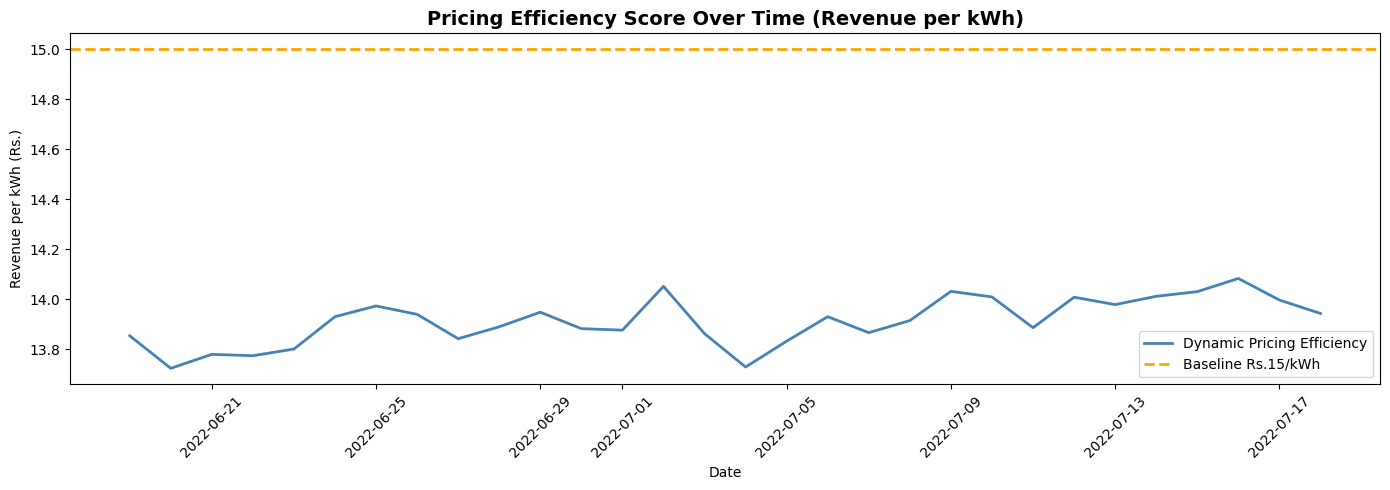

Avg Pricing Efficiency Score: Rs.13.9125/kWh
Baseline Efficiency: Rs.15/kWh
Difference: Rs.-1.0875/kWh


In [58]:
df_tariff['date'] = pd.to_datetime(df_tariff['datetime']).dt.date

daily_efficiency = df_tariff.groupby('date').apply(
    lambda x: x['revenue_dynamic'].sum() / x['volume'].sum()
).reset_index()
daily_efficiency.columns = ['date', 'pricing_efficiency_score']

baseline_efficiency = BASELINE_TARIFF  # ₹15 per kWh flat

plt.figure(figsize=(14, 5))
plt.plot(daily_efficiency['date'], daily_efficiency['pricing_efficiency_score'],
         color='steelblue', linewidth=2, label='Dynamic Pricing Efficiency')
plt.axhline(y=baseline_efficiency, color='orange', linestyle='--',
            linewidth=2, label='Baseline Rs.15/kWh')
plt.title('Pricing Efficiency Score Over Time (Revenue per kWh)', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Revenue per kWh (Rs.)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(f'{PLOTS}/13_pricing_efficiency.png', dpi=150)
plt.show()

avg_efficiency = daily_efficiency['pricing_efficiency_score'].mean()
print(f"Avg Pricing Efficiency Score: Rs.{avg_efficiency:.4f}/kWh")
print(f"Baseline Efficiency: Rs.{baseline_efficiency}/kWh")
print(f"Difference: Rs.{avg_efficiency - baseline_efficiency:.4f}/kWh")

Monitoring Feedback Loop (Agentic Learning)

In [59]:
# Monitoring Agent Feedback Loop

print("\nMONITORING AGENT FEEDBACK LOOP")

if avg_efficiency > baseline_efficiency:
    pricing_feedback = "Dynamic pricing performing better than baseline pricing."
else:
    pricing_feedback = "Review pricing thresholds for improved efficiency."

if wait_reduction > 0:
    congestion_feedback = "Dynamic pricing helping reduce congestion."
else:
    congestion_feedback = "Additional peak-period control may be required."

if customer_response_rate > 0:
    response_feedback = "Customers responding positively to tariff changes."
else:
    response_feedback = "Consider stronger off-peak incentives."

print(f"Pricing Feedback: {pricing_feedback}")
print(f"Congestion Feedback: {congestion_feedback}")
print(f"Customer Feedback: {response_feedback}")


MONITORING AGENT FEEDBACK LOOP
Pricing Feedback: Review pricing thresholds for improved efficiency.
Congestion Feedback: Dynamic pricing helping reduce congestion.
Customer Feedback: Customers responding positively to tariff changes.


Autonomous Pricing Adjustment

In [60]:
# Autonomous Pricing Adjustment

surge_threshold = 0.80
discount_threshold = 0.30

if wait_reduction <= 0:
    surge_threshold = 0.75

if customer_response_rate <= 0:
    discount_threshold = 0.35

print("Autonomus Pricing Adjustment")

print(f"Updated Surge Threshold: {surge_threshold:.2f}")
print(f"Updated Discount Threshold: {discount_threshold:.2f}")

Autonomus Pricing Adjustment
Updated Surge Threshold: 0.80
Updated Discount Threshold: 0.30


Saving Monitoring Agent

In [61]:
monitoring_metrics = pd.DataFrame({
    'metric': ['Avg Wait Before', 'Avg Wait After', 'Waiting Time Reduction %',
               'Customer Response Rate %',
               'Avg Pricing Efficiency Score (₹/kWh)', 'Baseline Efficiency (₹/kWh)',
               'Efficiency Difference (Rs./kWh)'],
    'value':  [avg_wait_before, avg_wait_after, wait_reduction,
               customer_response_rate,
               avg_efficiency, baseline_efficiency,
               avg_efficiency - baseline_efficiency]
})
monitoring_metrics.to_csv(f'{CSV_OUT}/monitoring_agent_metrics.csv', index=False)
print("Monitoring agent metrics saved!")
print(monitoring_metrics)

Monitoring agent metrics saved!
                                 metric   value
0                       Avg Wait Before  0.0001
1                        Avg Wait After  0.0001
2              Waiting Time Reduction %  9.5597
3              Customer Response Rate %  5.5474
4  Avg Pricing Efficiency Score (₹/kWh) 13.9125
5           Baseline Efficiency (₹/kWh) 15.0000
6       Efficiency Difference (Rs./kWh) -1.0875


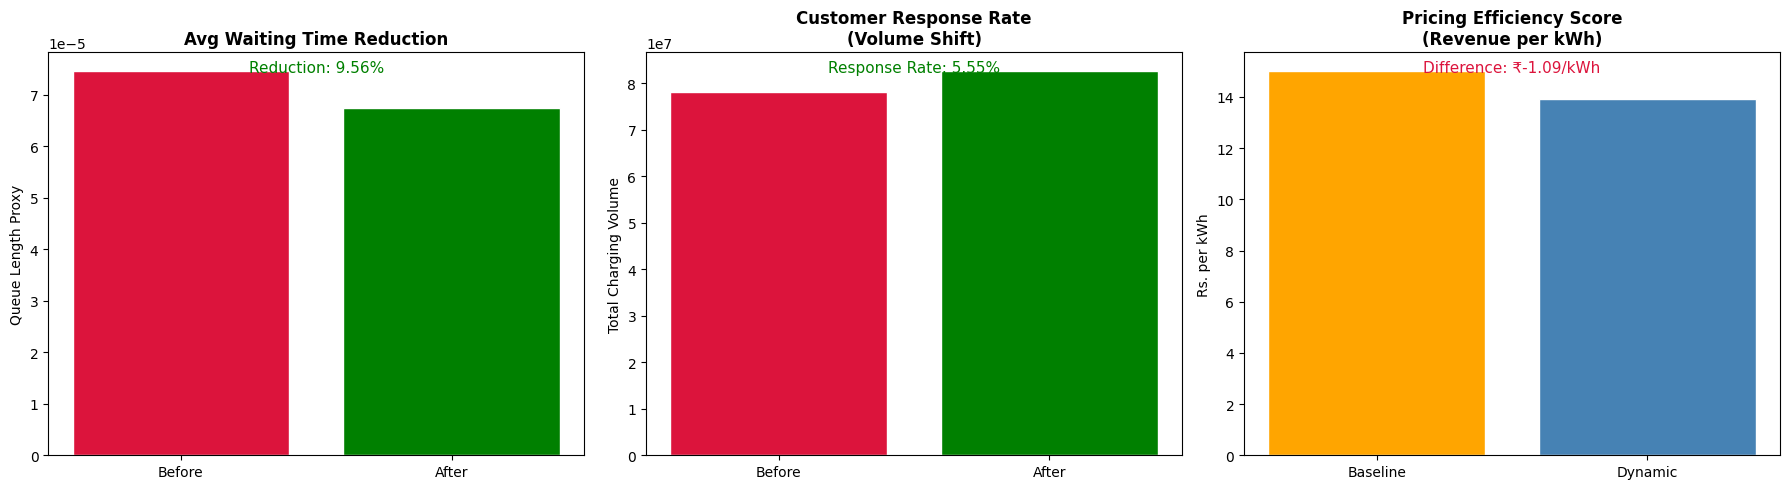

Monitoring & Learning Agent evaluation complete!


In [62]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Waiting Time Reduction
axes[0].bar(['Before', 'After'], [avg_wait_before, avg_wait_after],
            color=['crimson', 'green'], edgecolor='white')
axes[0].set_title('Avg Waiting Time Reduction', fontweight='bold')
axes[0].set_ylabel('Queue Length Proxy')
axes[0].text(0.5, 0.95, f'Reduction: {wait_reduction:.2f}%',
             transform=axes[0].transAxes, ha='center', fontsize=11, color='green')

# Plot 2: Customer Response Rate
axes[1].bar(['Before', 'After'], [total_vol_before, total_vol_after],
            color=['crimson', 'green'], edgecolor='white')
axes[1].set_title('Customer Response Rate\n(Volume Shift)', fontweight='bold')
axes[1].set_ylabel('Total Charging Volume')
axes[1].text(0.5, 0.95, f'Response Rate: {customer_response_rate:.2f}%',
             transform=axes[1].transAxes, ha='center', fontsize=11, color='green')

# Plot 3: Pricing Efficiency Score
axes[2].bar(['Baseline', 'Dynamic'], [baseline_efficiency, avg_efficiency],
            color=['orange', 'steelblue'], edgecolor='white')
axes[2].set_title('Pricing Efficiency Score\n(Revenue per kWh)', fontweight='bold')
axes[2].set_ylabel('Rs. per kWh')
axes[2].text(0.5, 0.95, f'Difference: ₹{avg_efficiency - baseline_efficiency:.2f}/kWh',
             transform=axes[2].transAxes, ha='center', fontsize=11, color='crimson')

plt.tight_layout()
plt.savefig(f'{PLOTS}/14_monitoring_agent_summary.png', dpi=150)
plt.show()
print("Monitoring & Learning Agent evaluation complete!")

Final Summary

In [63]:
print("AGENTIC AI DYNAMIC TARIFF OPTIMIZATION SUMMARY")

print("\n-- DEMAND PREDICTION AGENT --")
print(f"Utilization Rate-RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")
print(f"Charging Load-RMSE: {rmse_load:.4f} | MAE: {mae_load:.4f} | R²: {r2_load:.4f}")
print(f"Avg Congestion Probability: {congestion_prob.mean():.4f}")

print("\n-- TARIFF PRICING AGENT --")
print(f"Revenue Gain %: {revenue_gain_pct:.2f}%")
print(f"Utilization Improvement: {((avg_util_after - avg_util_before)/avg_util_before)*100:.2f}%")
print(f"Off-Peak Uplift: {off_peak_uplift:.2f}%")

print("\n-- MONITORING & LEARNING AGENT --")
print(f"Waiting Time Reduction: {wait_reduction:.2f}%")
print(f"Customer Response Rate: {customer_response_rate:.2f}%")
print(f"Pricing Efficiency Score: Rs.{avg_efficiency:.4f}/kWh")

print("\n-- OUTPUT FILES --")
print(f"Plots saved: {PLOTS}")
print(f"CSVs saved: {CSV_OUT}")
print(f"Processed data: {PROCESSED}")


AGENTIC AI DYNAMIC TARIFF OPTIMIZATION SUMMARY

-- DEMAND PREDICTION AGENT --
Utilization Rate-RMSE: 0.0285 | MAE: 0.0183 | R²: 0.9681
Charging Load-RMSE: 13.4637 | MAE: 4.7843 | R²: 0.9825
Avg Congestion Probability: 0.0063

-- TARIFF PRICING AGENT --
Revenue Gain %: -7.21%
Utilization Improvement: 7.34%
Off-Peak Uplift: 15.00%

-- MONITORING & LEARNING AGENT --
Waiting Time Reduction: 9.56%
Customer Response Rate: 5.55%
Pricing Efficiency Score: Rs.13.9125/kWh

-- OUTPUT FILES --
Plots saved: /content/drive/MyDrive/SocBiz_Analytics_Project/outputs/plots
CSVs saved: /content/drive/MyDrive/SocBiz_Analytics_Project/outputs/csv
Processed data: /content/drive/MyDrive/SocBiz_Analytics_Project/data/processed
